# 🤖 Agente ReAct con LangGraph

Implementación del grafo LangGraph basado en el diagrama:

```
INICIO
  └─> ENTRADA Y FILTRO (SEGURIDAD)
        └─> AGENTE / LLM  <──────────────────────────┐
              │  ↕ LEER/ESCRIBIR                      │
         MEMORIA DE CHAT                              │
              │                                       │
              ├─> HERRAMIENTAS (RAG / API Clima / Export)
              │         └─> OBSERVACIÓN / SALIDA ─────┘
              │
              └─> RESPUESTA Y FILTRO (CONTROL)
                        └─> FIN
```

**Bucle ReAct**: DECISIÓN → ACCIÓN → OBSERVACIÓN (se repite hasta que el agente decide responder)

## 📦 1. Instalación de dependencias

In [15]:
!pip install -q langgraph langchain langchain-openai langchain-community \
    langchain-core faiss-cpu tiktoken python-dotenv requests


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
pip install langchain-openai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## ⚙️ 2. Configuración de variables de entorno

In [17]:
from langchain_openai import AzureOpenAIEmbeddings
import os
from dotenv import load_dotenv

load_dotenv()

embeddings = AzureOpenAIEmbeddings(
    azure_deployment=os.getenv("AZURE_OPENAI_EMBEDDINGS_DEPLOYMENT"),  # "text-embedding-ada-002"
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
)


## 📚 3. Importaciones

In [18]:
import json
import datetime
import requests
from typing import Annotated, Literal

# LangChain core
from langchain_core.messages import (
    AIMessage, HumanMessage, SystemMessage,
    ToolMessage, BaseMessage
)
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# LangChain OpenAI
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# LangChain Community (RAG)
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

# Typing
from typing_extensions import TypedDict

print("✅ Importaciones completadas.")

✅ Importaciones completadas.


## 🗃️ 4. Estado del grafo (AgentState)

El estado es la "memoria de trabajo" que se comparte entre todos los nodos del grafo.

In [19]:
class AgentState(TypedDict):
    """Estado compartido entre todos los nodos del grafo."""
    messages: Annotated[list[BaseMessage], add_messages]
    user_input: str
    final_response: str
    blocked: bool
    iteration_count: int
    chat_export: list[dict]
    
    # Claves para resultados de búsquedas paralelas
    resultado_rag: str
    resultado_clima: str

print("✅ AgentState definido para búsquedas paralelas.")


✅ AgentState definido.


## 🔍 5. Base de conocimiento RAG

Creamos un vectorstore FAISS con documentos de ejemplo. En producción cargarías PDFs, webs, etc.

In [20]:
import os
from dotenv import load_dotenv
from langchain_openai import AzureOpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# 1. Cargar las variables de tu archivo .env
load_dotenv()

SAMPLE_DOCS = [
    "LangGraph es un framework de flujos de trabajo basado en grafos para agentes de IA. "
    "Permite definir nodos (funciones) y aristas (conexiones) para orquestar LLMs.",
    "LangChain es una librería Python para construir aplicaciones con LLMs. "
    "Proporciona herramientas para chains, agentes, memoria y retrieval.",
    "El patrón ReAct (Razonamiento + Actuación) permite a los LLMs razonar sobre "
    "qué herramientas usar, ejecutarlas y observar los resultados iterativamente.",
    "FAISS (Facebook AI Similarity Search) es una librería para búsqueda eficiente "
    "de vectores de embeddings. Se usa mucho en sistemas RAG.",
    "Los agentes de IA pueden usar herramientas como APIs del clima, bases de datos, "
    "o buscadores web para obtener información actualizada y responder preguntas."
]

# 2. Construir el vectorstore usando la configuración de AZURE
embeddings = AzureOpenAIEmbeddings(
    azure_deployment=os.environ.get("AZURE_OPENAI_EMBEDDINGS_DEPLOYMENT"),
    openai_api_version=os.environ.get("AZURE_OPENAI_API_VERSION"),
    azure_endpoint=os.environ.get("AZURE_OPENAI_ENDPOINT"),
    api_key=os.environ.get("AZURE_OPENAI_API_KEY")
)

docs = [Document(page_content=text) for text in SAMPLE_DOCS]

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

vectorstore = FAISS.from_documents(split_docs, embeddings)
retriever   = vectorstore.as_retriever(search_kwargs={"k": 2})

print(f"✅ Vectorstore RAG creado con {len(split_docs)} fragmentos.")

✅ Vectorstore RAG creado con 5 fragmentos.


## 🛠️ 6. Herramientas del agente

Implementamos las tres herramientas del diagrama: **RAG**, **API Clima** y **Exportar Chat**.

In [21]:
# ─────────────────────────────────────────────────────────
# HERRAMIENTA 1: Búsqueda RAG
# ─────────────────────────────────────────────────────────
@tool
def busqueda_rag(query: str) -> str:
    """Busca información en la base de conocimiento interna usando RAG (Retrieval-Augmented Generation).
    Úsala cuando necesites información sobre LangChain, LangGraph, IA o temas de la base de datos.

    Args:
        query: La pregunta o términos de búsqueda.
    """
    docs = retriever.invoke(query)
    if not docs:
        return "No se encontraron resultados relevantes en la base de conocimiento."
    resultados = "\n\n".join(
        [f"[Fragmento {i+1}]: {d.page_content}" for i, d in enumerate(docs)]
    )
    return f"📚 Resultados RAG para '{query}':\n{resultados}"


# ─────────────────────────────────────────────────────────
# HERRAMIENTA 2: API del Clima
# ─────────────────────────────────────────────────────────
@tool
def api_clima(ciudad: str) -> str:
    """Obtiene el clima actual de una ciudad usando la API de OpenWeatherMap.
    Úsala cuando el usuario pregunte por el tiempo, temperatura o condiciones meteorológicas.

    Args:
        ciudad: Nombre de la ciudad (en español o inglés).
    """
    if not OPENWEATHER_API_KEY:
        # Respuesta simulada si no hay API key
        return (
            f"🌤️ [SIMULADO] Clima en {ciudad}: 22°C, parcialmente nublado. "
            "Humedad: 60%. Viento: 15 km/h. "
            "(Configura OPENWEATHER_API_KEY para datos reales)"
        )

    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "q": ciudad,
        "appid": OPENWEATHER_API_KEY,
        "units": "metric",
        "lang": "es"
    }
    try:
        resp = requests.get(url, params=params, timeout=5)
        resp.raise_for_status()
        data = resp.json()
        desc   = data["weather"][0]["description"].capitalize()
        temp   = data["main"]["temp"]
        feels  = data["main"]["feels_like"]
        hum    = data["main"]["humidity"]
        viento = data["wind"]["speed"]
        return (
            f"🌡️ Clima en {ciudad}: {desc}. "
            f"Temperatura: {temp}°C (sensación: {feels}°C). "
            f"Humedad: {hum}%. Viento: {viento} m/s."
        )
    except requests.exceptions.HTTPError as e:
        if resp.status_code == 404:
            return f"❌ Ciudad '{ciudad}' no encontrada. Verifica el nombre."
        return f"❌ Error HTTP {resp.status_code}: {e}"
    except Exception as e:
        return f"❌ Error al consultar el clima: {str(e)}"


# ─────────────────────────────────────────────────────────
# HERRAMIENTA 3: Exportar Chat
# ─────────────────────────────────────────────────────────
@tool
def exportar_chat(formato: str = "txt") -> str:
    """Exporta el historial del chat actual a un archivo. 
    Úsala cuando el usuario pida guardar, descargar o exportar la conversación.

    Args:
        formato: Formato de exportación ('txt' o 'json').
    """
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename  = f"chat_export_{timestamp}.{formato}"

    # Nota: en el nodo real, el historial completo se pasará desde el estado.
    # Aquí generamos un archivo de placeholder.
    contenido = (
        f"Exportación del chat - {datetime.datetime.now().isoformat()}\n"
        "(El historial completo se guarda desde el estado del grafo)\n"
    )
    if formato == "json":
        contenido = json.dumps({"timestamp": timestamp, "nota": "Exportación desde LangGraph"}, indent=2)

    with open(filename, "w", encoding="utf-8") as f:
        f.write(contenido)

    return f"✅ Chat exportado correctamente como '{filename}'."


# Lista de herramientas disponibles
TOOLS = [busqueda_rag, api_clima, exportar_chat]
print(f"✅ {len(TOOLS)} herramientas registradas: {[t.name for t in TOOLS]}")

✅ 3 herramientas registradas: ['busqueda_rag', 'api_clima', 'exportar_chat']


## 🧠 7. Modelo LLM con herramientas vinculadas

In [22]:
import os
from dotenv import load_dotenv
from langchain_openai import AzureChatOpenAI

# 1. Cargar las variables del archivo .env
load_dotenv()
OPENWEATHER_API_KEY = os.getenv("OPENWEATHER_API_KEY")
# 2. Instanciar el modelo usando la clase de Azure
llm = AzureChatOpenAI(
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT"),  # Ej: gpt-4o-mini
    openai_api_version=os.getenv("AZURE_OPENAI_API_VERSION"), # Ej: 2024-02-01
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    temperature=0  # 0 = respuestas más deterministas
)

# 3. Vincular las herramientas al modelo (asegúrate de que TOOLS esté definido previamente)
llm_con_tools = llm.bind_tools(TOOLS)

print("✅ LLM configurado y herramientas vinculadas.")

✅ LLM configurado y herramientas vinculadas.


## 🏗️ 8. Nodos del grafo

Implementamos cada nodo del diagrama como una función Python.

In [23]:
# ─── Control de verbosidad de los nodos ───────────────────────
VERBOSE_NODES = True   # ← Activado para ver la paralelización
# ──────────────────────────────────────────────────────────────

PATRONES_BLOQUEADOS = [
    "hack", "exploit", "malware", "virus", "bomba", "arma",
    "contraseña", "password", "crack", "robar", "ilegal",
    "inject", "sql injection", "xss", "bypass"
]

def nodo_entrada_filtro(state: AgentState) -> AgentState:
    if VERBOSE_NODES: print("\n🔒 [NODO] Entrada y Filtro de Seguridad")
    ultimo_mensaje = state["messages"][-1]
    user_input = ultimo_mensaje.content if hasattr(ultimo_mensaje, "content") else ""
    input_lower = user_input.lower()

    if len(user_input.strip()) < 2:
        return {**state, "user_input": user_input, "blocked": True, "final_response": "⚠️ Por favor, escribe una pregunta más completa."}

    for patron in PATRONES_BLOQUEADOS:
        if patron in input_lower:
            return {**state, "user_input": user_input, "blocked": True, "final_response": f"🚫 Mensaje bloqueado. Patrón: {patron}"}

    return {**state, "user_input": user_input, "blocked": False, "iteration_count": 0}

# ─────────────────────────────────────────────────────────────────────────────
# NODO BÚSQUEDA PARALELA 1: RAG
# ─────────────────────────────────────────────────────────────────────────────
def nodo_busqueda_rag(state: AgentState) -> dict:
    if VERBOSE_NODES: print("\n🔍 [PARALELO] Búsqueda en Base de Conocimiento (RAG)")
    query = state.get("user_input", "")
    try:
        resultado = busqueda_rag.invoke(query)
    except Exception as e:
        resultado = f"Error en búsqueda RAG: {e}"
    if VERBOSE_NODES: print(f"  📚 Resultado RAG: '{str(resultado)[:50]}...'")
    return {"resultado_rag": str(resultado)}

# ─────────────────────────────────────────────────────────────────────────────
# NODO BÚSQUEDA PARALELA 2: CLIMA
# ─────────────────────────────────────────────────────────────────────────────
def nodo_intento_clima(state: AgentState) -> dict:
    import re
    if VERBOSE_NODES: print("\n⛅ [PARALELO] Intento de Búsqueda de Clima")
    user_input = state.get("user_input", "")
    
    # Extracción muy simple de ciudad usando una heurística rápida
    ciudad = ""
    match = re.search(r'(en|de)\s+([A-ZÁÉÍÓÚÑa-záéíóúñ]+)', user_input)
    if match:
        ciudad = match.group(2)
    
    if ciudad:
        try:
            resultado = api_clima.invoke(ciudad)
        except Exception as e:
            resultado = f"Error en API Clima: {e}"
    else:
        resultado = "No se detectó una ciudad clara en el mensaje."
        
    if VERBOSE_NODES: print(f"  ☁️ Resultado Clima: '{str(resultado)[:50]}...'")
    return {"resultado_clima": str(resultado)}

# ─────────────────────────────────────────────────────────────────────────────
# NODO FAN-IN: SÍNTESIS DE RESPUESTA
# ─────────────────────────────────────────────────────────────────────────────
def nodo_sintesis_respuesta(state: AgentState) -> dict:
    if VERBOSE_NODES: print("\n⚖️ [NODO] Agente: Síntesis de Resultados de Búsqueda")
    rag = state.get("resultado_rag", "")
    clima = state.get("resultado_clima", "")
    prompt = f"""El usuario ha preguntado: {state['user_input']}
    
Han finalizado las siguientes búsquedas automáticas en paralelo:
[RESULTADOS RAG]: {rag}
[RESULTADOS CLIMA]: {clima}

Por favor, elabora la mejor respuesta posible al usuario. Usa solo la información relevante de las búsquedas."""
    
    respuesta = llm.invoke([SystemMessage(content="Eres un asistente que sintetiza múltiples resultados de búsqueda."), HumanMessage(content=prompt)])
    return {"messages": [respuesta]}

def nodo_respuesta_filtro(state: AgentState) -> AgentState:
    if VERBOSE_NODES: print("\n✅ [NODO] Respuesta y Filtro (Control)")
    if state.get("blocked"): return state

    ultimo = next((m for m in reversed(state["messages"]) if isinstance(m, AIMessage)), None)
    respuesta_raw = ultimo.content if ultimo else "No se generó respuesta."

    historial = state.get("chat_export", [])
    historial.append({
        "timestamp": datetime.datetime.now().isoformat(),
        "user": state.get("user_input", ""),
        "assistant": str(respuesta_raw)
    })

    return {**state, "final_response": str(respuesta_raw), "chat_export": historial}


✅ Todos los nodos definidos.


## 🔀 9. Lógica de enrutamiento (aristas condicionales)

In [24]:
def router_despues_filtro_entrada(state: AgentState) -> list[str]:
    """Después del filtro de entrada:
    - Si fue bloqueado → ir a respuesta_filtro.
    - Si está permitido → lanzar búsquedas en paralelo.
    """
    if state.get("blocked"):
        print("  🔀 Router: bloqueado → respuesta_filtro")
        return ["respuesta_filtro"]
    print("  🔀 Router: permitido → ejecutando búsquedas paralelas (RAG y Clima)")
    return ["nodo_busqueda_rag", "nodo_intento_clima"]


✅ Funciones de enrutamiento definidas.


## 🏗️ 10. Construcción del grafo LangGraph

Conectamos todos los nodos y aristas según el diagrama.

In [25]:
# ─────────────────────────────────────────────
# Definición del grafo (Opción B: Búsquedas Paralelas)
# ─────────────────────────────────────────────
builder = StateGraph(AgentState)

builder.add_node("entrada_filtro", nodo_entrada_filtro)
builder.add_node("nodo_busqueda_rag", nodo_busqueda_rag)
builder.add_node("nodo_intento_clima", nodo_intento_clima)
builder.add_node("sintesis_respuesta", nodo_sintesis_respuesta)
builder.add_node("respuesta_filtro", nodo_respuesta_filtro)

# Arista de inicio
builder.add_edge(START, "entrada_filtro")

# FAN-OUT: Lanzar múltiples búsquedas a la vez
builder.add_conditional_edges(
    "entrada_filtro",
    router_despues_filtro_entrada,
    ["respuesta_filtro", "nodo_busqueda_rag", "nodo_intento_clima"]
)

# FAN-IN: Ambas búsquedas convergen en el agente de síntesis
builder.add_edge("nodo_busqueda_rag", "sintesis_respuesta")
builder.add_edge("nodo_intento_clima", "sintesis_respuesta")

# De la síntesis al filtro final
builder.add_edge("sintesis_respuesta", "respuesta_filtro")
builder.add_edge("respuesta_filtro", END)

memory = MemorySaver()
grafo = builder.compile(checkpointer=memory)

print("✅ Grafo LangGraph compilado en paralelo correctamente.")
print("Nodos:",  list(grafo.get_graph().nodes.keys()))


✅ Grafo LangGraph compilado correctamente.

Nodos: ['__start__', 'entrada_filtro', 'agente', 'herramientas', 'respuesta_filtro', '__end__']


## 📊 11. Visualización del grafo

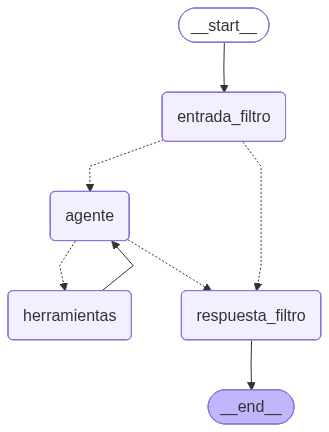

✅ Grafo visualizado.


In [26]:
try:
    from IPython.display import Image, display
    imagen = grafo.get_graph().draw_mermaid_png()
    display(Image(imagen))
    print("✅ Grafo visualizado.")
except Exception as e:
    print(f"ℹ️  No se pudo renderizar la imagen del grafo: {e}")
    print("   (Instala 'pygraphviz' o 'grandalf' para visualización)")
    print()
    # Mostrar representación en texto
    print("Estructura del grafo (Mermaid):")
    print(grafo.get_graph().draw_mermaid())

## 💬 12. Función de invocación del agente

In [27]:
def invocar_agente(
    mensaje: str,
    thread_id: str = "hilo-principal",
    verbose: bool = True
) -> str:
    """Invoca el agente con un mensaje del usuario."""
    config = {"configurable": {"thread_id": thread_id}}

    # ✅ FIX: Recuperar chat_export existente del checkpoint para no resetearlo
    estado_existente = grafo.get_state(config)
    chat_export_actual = []
    if estado_existente and estado_existente.values:
        chat_export_actual = estado_existente.values.get("chat_export", [])

    if verbose:
        print("=" * 60)
        print(f"👤 USUARIO: {mensaje}")
        print("=" * 60)

    estado_inicial = {
        "messages":       [HumanMessage(content=mensaje)],
        "user_input":     mensaje,
        "final_response": "",
        "blocked":        False,
        "iteration_count": 0,
        "chat_export":    chat_export_actual,   # ← preserva historial acumulado
    }

    resultado = grafo.invoke(estado_inicial, config=config)
    respuesta = resultado.get("final_response", "Sin respuesta generada.")

    if verbose:
        print()
        print("=" * 60)
        print("🤖 RESPUESTA FINAL:")
        print(respuesta)
        print("=" * 60)

    return respuesta

print("✅ Función de invocación lista.")


✅ Función de invocación lista.


## 💬 14. Modo Chat Interactivo

Ejecuta esta celda para chatear con el agente en tiempo real.

In [28]:
print("💬 Chat Interactivo con el Agente ReAct")
print("  Escribe 'salir' o 'exit' para terminar.")
print("─" * 50)

SESSION_ID = "sesion-interactiva"

while True:
    try:
        user_input = input("\n👤 Tú: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\n👋 Chat finalizado.")
        break

    if not user_input:
        continue

    if user_input.lower() in ["salir", "exit", "quit"]:
        print("👋 ¡Hasta luego!")
        break

    # verbose=False para output limpio; los nodos ya son silenciosos con VERBOSE_NODES=False
    respuesta = invocar_agente(user_input, thread_id=SESSION_ID, verbose=False)
    print(f"\n🤖 Agente: {respuesta}")


💬 Chat Interactivo con el Agente ReAct
  Escribe 'salir' o 'exit' para terminar.
──────────────────────────────────────────────────
  🔀 Router: permitido → agente
  🔀 Router: respuesta final → respuesta_filtro

🤖 Agente: ¡Hola! ¿Cómo puedo ayudarte hoy?

---
🔄 *Iteraciones ReAct: 1 | Conversación activa*
👋 ¡Hasta luego!


## 📁 15. Ver historial exportable del chat

In [29]:
# Celda 15 — cambia a la sesión del chat interactivo
config_memoria = {"configurable": {"thread_id": "sesion-interactiva"}}  # ← este es el tuyo
estado_actual = grafo.get_state(config_memoria)

if estado_actual and estado_actual.values:
    historial = estado_actual.values.get("chat_export", [])
    print(f"📋 Historial de la sesión 'sesion-interactiva' ({len(historial)} turnos):")
    print()
    for i, turno in enumerate(historial, 1):
        print(f"── Turno {i} [{turno['timestamp']}] ──")
        print(f"   👤 {turno['user']}")
        print(f"   🤖 {turno['assistant'][:200]}..."
              if len(turno['assistant']) > 200
              else f"   🤖 {turno['assistant']}")
        print()
else:
    print("ℹ️  No hay historial para esta sesión aún.")


📋 Historial de la sesión 'sesion-interactiva' (1 turnos):

── Turno 1 [2026-06-09T11:18:00.153778] ──
   👤 hola
   🤖 ¡Hola! ¿Cómo puedo ayudarte hoy?

---
🔄 *Iteraciones ReAct: 1 | Conversación activa*



---

## 📌 Resumen de la arquitectura

| Nodo | Función | Equivalente en diagrama |
|------|---------|------------------------|
| `entrada_filtro` | Valida y filtra el input del usuario | ENTRADA Y FILTRO (SEGURIDAD) |
| `agente` | LLM con tool calling (ReAct: DECISIÓN) | AGENTE / LLM |
| `herramientas` | Ejecuta RAG, Clima, Export (ACCIÓN) | HERRAMIENTAS + OBSERVACIÓN/SALIDA |
| `respuesta_filtro` | Formatea y valida la respuesta final | RESPUESTA Y FILTRO (CONTROL) |
| `messages` en estado | Historial completo de la conversación | MEMORIA DE CHAT |

### 🔄 Bucle ReAct

```
agente (DECISIÓN)
   ↓ si tool_calls
herramientas (ACCIÓN)
   ↓ resultado
agente (OBSERVACIÓN → nueva DECISIÓN)
   ↓ si respuesta final
respuesta_filtro → FIN
```